In [1]:
import pandas as pd
import numpy as np
import gc
import copy

from sklearn.model_selection import train_test_split
import torch
from PIL import Image
from open_clip import create_model_from_pretrained, get_tokenizer, create_model_and_transforms
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from transformers import AutoModel, AutoTokenizer
from torchvision import transforms
from sklearn.linear_model import LogisticRegression
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from peft import LoraConfig, get_peft_model
from torch.amp import autocast, GradScaler
from torchinfo import summary

In [4]:
pd.options.display.max_columns = None
dataset_sample = pd.read_csv("./chexpert_plus_dataset_sample.csv", index_col=0)
dataset_sample

,path_to_image,deid_patient_id,report,section_findings,section_impression,section_summary,target
0,train/patient29951/study1/view1_frontal.jpg,patient29951,NARRATIVE:\nChest 1 View: 7-8-2006\n \nHISTORY...,NaN,"\n \n1.LOW LUNG VOLUMES, WITH MINIMAL BASILAR ...",1-NO SIGNIFICANT ABNORMALITY \nI have personal...,1
1,train/patient03643/study1/view2_lateral.jpg,patient03643,NARRATIVE:\nCHEST AP PORTABLE: 11/1/2012\nCOMP...,NaN,\n1. REDEMONSTRATION OF A SMALL RIGHT PNEUMOTH...,"4: Possible significant abnormality/change, m...",0
2,train/patient32294/study1/view1_frontal.jpg,patient32294,NARRATIVE:\nTWO VIEWS OF THE CHEST: 3/1/2004.\...,NaN,\n \n1. PA AND LATERAL UPRIGHT VIEWS OF THE C...,"4-POSSIBLE SIGNIFICANT FINDINGS, MAY NEED ACTI...",0
3,train/patient33459/study1/view2_lateral.jpg,patient33459,NARRATIVE:\nEXAM: Chest 1 View december 23\n \...,NaN,\n \n1.SINGLE FRONTAL VIEW OF THE CHEST DEMONS...,"2-ABNORMAL, PREVIOUSLY REPORTED\nI have person...",0
4,train/patient01820/study2/view1_frontal.jpg,patient01820,"NARRATIVE:\nEXAM: Chest 2 Views, 12/20/16\n \n...",NaN,\n \n1.MILD RETICULAR OPACITIES ARE SEEN IN BO...,"4-POSSIBLY SIGNIFICANT FINDING, MAY NEED ACTIO...",1
...,...,...,...,...,...,...,...
35995,train/patient19113/study1/view1_frontal.jpg,patient19113,"NARRATIVE:\nEXAM: Chest 2 Views, 8-12-05.\n \n...",NaN,\n \n1.FRONTAL AND LATERAL RADIOGRAPHS OF THE ...,"2-ABNORMAL, PREVIOUSLY REPORTED\nI have person...",1
35996,train/patient48765/study5/view1_frontal.jpg,patient48765,NARRATIVE:\nSINGLE VIEW OF THE CHEST: 3/27/2...,Frontal radiograph of the chest performed o...,\n \n 1. INTERVAL REMOVAL OF LEFT CHEST TUB...,"4-POSSIBLE SIGNIFICANT FINDINGS, MAY NEED ACTI...",1
35997,train/patient45818/study3/view1_frontal.jpg,patient45818,"NARRATIVE:\nCHEST, ONE VIEW: 12/2/2013 1405\nC...",NaN,\n1. POSTOPERATIVE CHANGES WITH INTERVAL PLACE...,"2: ABNORMAL, PREVIOUSLY REPORTED\nI have pers...",1
35998,train/patient17330/study1/view1_frontal.jpg,patient17330,"NARRATIVE:\nPORTABLE CHEST, SINGLE VIEW: 9/9/2...",Single portable frontal view of the chest dem...,\n2. MODERATE INTERSTITIAL PULMONARY EDEMA WIT...,"4-POSSIBLE SIGNIFICANT FINDINGS, MAY NEED ACTI...",1


In [5]:
X = dataset_sample.drop(columns=["target"])
y = dataset_sample["target"]

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# BiomedCLIP

**For the report's text, we use the column "report" of the dataset for all the Models**

In [6]:
# Load the BiomedCLIP model and processor
model, preprocess = create_model_from_pretrained('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
tokenizer = get_tokenizer('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
model.eval()

CustomTextCLIP(
  (visual): TimmModel(
    (trunk): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
          

## Similarity score (cosine similarity) classification

* We pass the image and the text to the model encoders
* We get two vectors
* We compute the similarity score (cosine similarity) on these two vectors
* We classify the scores of the pairs images/texts into two classes Match=1 or Mismatch=0
* The classification depends on the computed similarity score threshold

In [6]:
# Extract the encoded image/text vectors and compute the similarity score between them
def check_biomed_clip_match(image_path, report_text):
    # Prepare inputs
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    text = tokenizer([report_text]).to(device)
    
    with torch.no_grad():
        # Get features
        image_features = model.encode_image(image)
        text_features = model.encode_text(text)
        
        # Normalize features
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        
        # Calculate similarity score (ranges roughly from -1 to 1, usually >0)
        similarity = (image_features @ text_features.T).item()
        
    return similarity

Test ROC-AUC Score: 0.6580
Optimal Similarity Threshold: 0.3931
Maximized True Positive Rate (Sensitivity): 0.5596
Minimized False Positive Rate (1 - Specificity): 0.3156


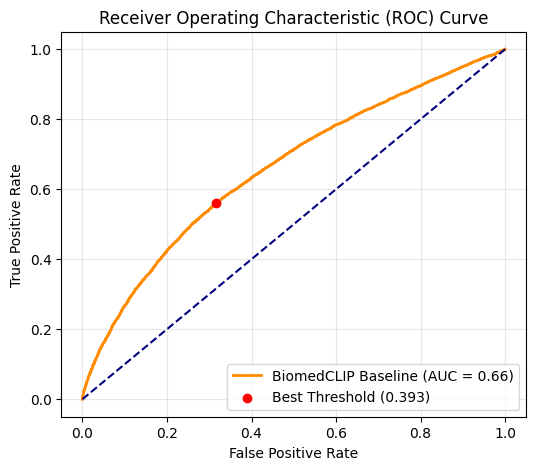

In [7]:
# Get the similarity scores on the train set
X_train["similarity_score"] = 0.0
for i in X_train.index:
    image_path = "./CheXpert/CheXpert-v1.0-small/" + X_train.loc[i, "path_to_image"]
    report_text = X_train.loc[i, "report"]
    X_train.loc[i, "similarity_score"] = check_biomed_clip_match(image_path, report_text)

# Function returning the similarity score threshold
def evaluate(targets, similarities):
    # Compute ROC-AUC Score
    auc = roc_auc_score(targets, similarities)
    print(f"Test ROC-AUC Score: {auc:.4f}")
    
    # Calculate ROC Curve metrics
    fpr, tpr, thresholds = roc_curve(targets, similarities)
    
    # Find optimal threshold
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]
    
    print(f"Optimal Similarity Threshold: {best_threshold:.4f}")
    print(f"Maximized True Positive Rate (Sensitivity): {tpr[best_idx]:.4f}")
    print(f"Minimized False Positive Rate (1 - Specificity): {fpr[best_idx]:.4f}")
    
    # Plot the ROC Curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'BiomedCLIP Baseline (AUC = {auc:.2f})', color='darkorange', lw=2)
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label=f'Best Threshold ({best_threshold:.3f})', zorder=5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return best_threshold

targets = y_train.to_numpy()
similarities = X_train["similarity_score"].to_numpy()
# Compute the similarity score threshold on the train set
opt_threshold = evaluate(targets, similarities)

In [8]:
# Display the metrics of the binary classification
def bin_classif_metrics(similarities, targets, opt_threshold, type='Train'):
    # Convert continuous similarity scores into binary predictions (0 or 1)
    predictions = (similarities >= opt_threshold).astype(int)

    # Calculate operational metrics
    accuracy = accuracy_score(targets, predictions)
    precision = precision_score(targets, predictions)  # Out of all predicted matches, how many are real?
    recall = recall_score(targets, predictions)        # Same as Sensitivity / True Positive Rate
    f1 = f1_score(targets, predictions)                # Harmonic mean of Precision and Recall

    # Extract Specificity (True Negative Rate) via Confusion Matrix
    # Matrix format: [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(targets, predictions).ravel()
    specificity = tn / (tn + fp)

    # Print the evaluation dashboard
    print(f"--- Operational Metrics at Threshold {opt_threshold} ---")
    print(f"{type} ROC-AUC Score: {roc_auc_score(targets, similarities):.4f}")
    print(f"{type} Accuracy:    {accuracy:.4f}")
    print(f"{type} Precision:   {precision:.4f}")
    print(f"{type} Recall:      {recall:.4f}")
    print(f"{type} F1-Score:    {f1:.4f}")
    print(f"{type} Specificity: {specificity:.4f} (FPR is {1-specificity:.4f})")

print("----------Train metrics-------------")
targets = y_train.to_numpy()
similarities = X_train["similarity_score"].to_numpy()
bin_classif_metrics(similarities, targets, opt_threshold, type='Train')

print("----------Test metrics-------------")
# Get the similarity scores on the train set
X_test["similarity_score"] = 0.0
for i in X_test.index:
    image_path = "./CheXpert/CheXpert-v1.0-small/" + X_test.loc[i, "path_to_image"]
    report_text = X_test.loc[i, "report"]
    X_test.loc[i, "similarity_score"] = check_biomed_clip_match(image_path, report_text)
targets = y_test.to_numpy()
similarities = X_test["similarity_score"].to_numpy()
bin_classif_metrics(similarities, targets, opt_threshold, type='Test')

----------Train metrics-------------
--- Operational Metrics at Threshold 0.3930705189704895 ---
Train ROC-AUC Score: 0.6580
Train Accuracy:    0.6220
Train Precision:   0.6394
Train Recall:      0.5596
Train F1-Score:    0.5968
Train Specificity: 0.6844 (FPR is 0.3156)
----------Test metrics-------------
--- Operational Metrics at Threshold 0.3930705189704895 ---
Test ROC-AUC Score: 0.6610
Test Accuracy:    0.6176
Test Precision:   0.6359
Test Recall:      0.5506
Test F1-Score:    0.5901
Test Specificity: 0.6847 (FPR is 0.3153)


## Simple logistic regression on encoded vectors

* We pass the image and the text to the model encoders
* We get two vectors
* We don't compute the similarity score between the vectors
* We concatenate these two vectors, plus the difference, plus element wise multiplication
* We get for every pair image/text one vector [img_emb, txt_emb, img_emb-txt_emb, img_emb*txt_emb]
* We pass the vectors to a logistic regression model: Match=1, Mismatch=0

In [9]:
# Just getting the encoded vectors image/text
def extract_multimodal_features(image_path, report_text):
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    text = tokenizer([report_text]).to(device)
    
    with torch.no_grad():
        image_features = model.encode_image(image)
        text_features = model.encode_text(text)
        
        # Normalize the vectors
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        # Move to CPU and convert to numpy for scikit-learn
        img_emb = image_features.cpu().numpy().flatten()
        txt_emb = text_features.cpu().numpy().flatten()
        
    # Combine features: Absolute difference and Element-wise product --> similarities and differences
    abs_diff = np.abs(img_emb - txt_emb)
    product = img_emb * txt_emb
    
    # Concatenate them to create a single robust feature vector for this pair
    combined_feature = np.concatenate([img_emb, txt_emb, abs_diff, product])
    return combined_feature

In [10]:
# Extract multimodal features for train and test sets:
reg_X_train = np.array([extract_multimodal_features(img, txt) for img, txt in zip(("./CheXpert/CheXpert-v1.0-small/" + X_train["path_to_image"]).tolist(), X_train["report"].tolist())])
reg_y_train = y_train.to_numpy()

reg_X_test = np.array([extract_multimodal_features(img, txt) for img, txt in zip(("./CheXpert/CheXpert-v1.0-small/" + X_test["path_to_image"]).tolist(), X_test["report"].tolist())])
reg_y_test = y_test.to_numpy()

In [11]:
# Train Logistic Regression
log_reg = LogisticRegression(max_iter=5000, random_state=42) 
log_reg.fit(reg_X_train, reg_y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [12]:
# Predict probabilities on the tain and test sets
# predict_proba returns [prob_of_0, prob_of_1]. We want prob_of_1.
y_probs_train = log_reg.predict_proba(reg_X_train)[:, 1]
y_preds_train = log_reg.predict(reg_X_train)
y_probs_test = log_reg.predict_proba(reg_X_test)[:, 1]
y_preds_test = log_reg.predict(reg_X_test)

# Evaluate
print("----------Train metrics-------------")
print(f"Train ROC-AUC Score: {roc_auc_score(reg_y_train, y_probs_train):.4f}")
print("Train Classification Report:")
print(classification_report(reg_y_train, y_preds_train))
print("----------Test metrics-------------")
print(f"Test ROC-AUC Score: {roc_auc_score(reg_y_test, y_probs_test):.4f}")
print("Test Classification Report:")
print(classification_report(reg_y_test, y_preds_test))

----------Train metrics-------------
Train ROC-AUC Score: 0.8427
Train Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.73      0.76     14400
           1       0.75      0.80      0.77     14400

    accuracy                           0.77     28800
   macro avg       0.77      0.77      0.77     28800
weighted avg       0.77      0.77      0.77     28800

----------Test metrics-------------
Test ROC-AUC Score: 0.8298
Test Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74      3600
           1       0.73      0.78      0.76      3600

    accuracy                           0.75      7200
   macro avg       0.75      0.75      0.75      7200
weighted avg       0.75      0.75      0.75      7200



## Cross Attention + MLP

* Due to the dimensions of generated tensors and the size of the dataset sample, training duration will be too long on the whole sample with the very high risk of out of memory exception
* That's why, we'll reduce the size of our sample (train+valid) to 22000 instead of the initial size of 36000
* We get the same results (almost no difference)

In [6]:
df_pos = dataset_sample.loc[dataset_sample["target"] == 1, :]
df_neg = dataset_sample.loc[dataset_sample["target"] == 0, :]

df_pos= df_pos.sample(11000, random_state=42).reset_index(drop=True)
df_neg= df_neg.sample(11000, random_state=42).reset_index(drop=True)

df_concat = pd.concat([df_pos,df_neg], ignore_index=True)
df_concat = df_concat.sample(frac=1, random_state=42).reset_index(drop=True)

X_cross_att = df_concat.drop(columns=["target"])
y_cross_att = df_concat["target"]

# Split with stratification
X_train_cross_att, X_test_cross_att, y_train_cross_att, y_test_cross_att = train_test_split(
    X_cross_att,
    y_cross_att,
    test_size=0.2,
    random_state=42,
    stratify=y_cross_att,
)

In [13]:
def biomed_clip_cross_att(image_path, report_text):
    # Prepare inputs
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    text = tokenizer([report_text]).to(device)
    
    with torch.no_grad():
            #  Extract Image Patches Embeddings
            # Output shape: [Batch, Num_Patches, Vision_Dim] (e.g., [B, 197, 768])
            # 197 includes 196 patches (14x14) + 1 CLS token
            img_patches = model.visual.trunk.forward_features(image)
            img_patches = img_patches[:, 1:, :] 

            # Extracts sequence embeddings from PubMedBERT before pooler squashing.
            # Input shape: [Batch_Size, Max_Sequence_Length] -> (usually 256 for BiomedCLIP)
            # Output shape: [Batch_Size, Max_Sequence_Length, Text_Dimension] -> e.g., [B, 256, 768]
            text_outputs = model.text.transformer(text)
            text_tokens = text_outputs.last_hidden_state

            img_patches_np = img_patches.squeeze(0).cpu().numpy()
            text_tokens_np = text_tokens.squeeze(0).cpu().numpy()
            
    return img_patches_np, text_tokens_np

In [16]:
cross_att_X_train_txt = []
cross_att_X_train_img = []
for i, (img, txt) in enumerate(zip(("./CheXpert/CheXpert-v1.0-small/" + X_train_cross_att["path_to_image"]).tolist(), X_train_cross_att["report"].tolist())):
    img_pat, txt_pat = biomed_clip_cross_att(img, txt)
    cross_att_X_train_img.append(img_pat)
    cross_att_X_train_txt.append(txt_pat)

    if i % 200 == 0 and i > 0:
        gc.collect()
        torch.cuda.empty_cache()

cross_att_y_train = y_train_cross_att.to_numpy()
cross_att_X_train_txt = np.array(cross_att_X_train_txt)
cross_att_X_train_img = np.array(cross_att_X_train_img)

In [17]:
cross_att_X_test_txt = []
cross_att_X_test_img = []
for i, (img, txt) in enumerate(zip(("./CheXpert/CheXpert-v1.0-small/" + X_test_cross_att["path_to_image"]).tolist(), X_test_cross_att["report"].tolist())):
    img_pat, txt_pat = biomed_clip_cross_att(img, txt)
    cross_att_X_test_img.append(img_pat)
    cross_att_X_test_txt.append(txt_pat)

    if i % 200 == 0 and i > 0:
        gc.collect()
        torch.cuda.empty_cache()

cross_att_y_test = y_test_cross_att.to_numpy()
cross_att_X_test_txt = np.array(cross_att_X_test_txt)
cross_att_X_test_img = np.array(cross_att_X_test_img)

In [22]:
cross_att_X_train_txt_tensor = torch.from_numpy(cross_att_X_train_txt).float()
cross_att_X_train_img_tensor = torch.from_numpy(cross_att_X_train_img).float()
cross_att_y_train_tensor = torch.from_numpy(cross_att_y_train).float()
cross_att_train_dataset = TensorDataset(cross_att_X_train_img_tensor, cross_att_X_train_txt_tensor, cross_att_y_train_tensor)
cross_att_X_test_txt_tensor = torch.from_numpy(cross_att_X_test_txt).float()
cross_att_X_test_img_tensor = torch.from_numpy(cross_att_X_test_img).float()
cross_att_y_test_tensor = torch.from_numpy(cross_att_y_test).float()
cross_att_test_dataset = TensorDataset(cross_att_X_test_img_tensor, cross_att_X_test_txt_tensor, cross_att_y_test_tensor)

cross_att_train_loader = DataLoader(cross_att_train_dataset, batch_size=64, shuffle=True)
cross_att_val_loader = DataLoader(cross_att_test_dataset, batch_size=64, shuffle=False)

In [23]:
# Cross-Attention+MLP Model
class CrossAttentionClassifier(nn.Module):
    def __init__(self, embed_dim=768, num_heads=8, dropout=0.3):
        super().__init__()
        
        self.cross_attention = nn.MultiheadAttention(
                    embed_dim=embed_dim, 
                    num_heads=num_heads, 
                    dropout=dropout,
                    batch_first=True
                )
        
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.layer_norm2 = nn.LayerNorm(embed_dim)
    
        # Add a small Feed-Forward Network layer (FFN) inside the attention block 
        # This mirrors a true standard Transformer block and stabilizes representation warping
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim)
        )
    
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.LayerNorm(256), # BatchNorm stabilizes linear scaling transitions!
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )
        
    def forward(self, img_patches, text_tokens):
        norm_text = self.layer_norm1(text_tokens)
        # Cross-Attention Core
        attn_output, _ = self.cross_attention(
            query=norm_text, 
            key=img_patches, 
            value=img_patches
        )
        x = (attn_output + text_tokens)
        
        # FFN stabilization step
        x = self.layer_norm2(self.ffn(x)) + x
        
        # Max-pooling across sequence dimension 
        # This captures the strongest text-visual features and ignores inactive padding tokens
        x_pooled, _ = torch.max(x, dim=1)
        # Predict
        return self.classifier(x_pooled)

In [24]:
def cross_attention_train(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=100, patience=3):
    """
    Function to train a PyTorch model with training and validation datasets.

    Parameters:
    model: The neural network model to train.
    train_loader: DataLoader for the training dataset.
    val_loader: DataLoader for the validation dataset.
    criterion: Loss function (e.g., Binary Cross Entropy for classification).
    optimizer: Optimization algorithm (e.g., Adam, SGD).
    epochs: Number of training epochs (default=100).

    Returns:
    history: Dictionary containing loss and accuracy for both training and validation.
    """

    # Dictionary to store training & validation loss and accuracy over epochs
    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

    # Early stopping trackers
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = None
    best_epoch = 0

    for epoch in range(epochs):  # Loop over the number of epochs
        model.train()  # Set model to training mode
        total_loss, correct = 0, 0  # Initialize total loss and correct predictions

        # Training loop
        for inputs_img, inputs_txt, labels in train_loader:
            inputs_img = inputs_img.to(device)
            inputs_txt = inputs_txt.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()  # Reset gradients before each batch
            outputs = model(inputs_img, inputs_txt).squeeze(1)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backpropagation (compute gradients)
            optimizer.step()  # Update model parameters

            total_loss += loss.item()  # Accumulate batch loss
            correct += ((torch.sigmoid(outputs) >= 0.5).float() == labels).sum().item()  # Count correct predictions

        # Compute average loss and accuracy for training
        train_loss = total_loss / len(train_loader)
        train_acc = correct / len(train_loader.dataset)

        # Validation phase (without gradient computation)
        model.eval()  # Set model to evaluation mode
        val_loss, val_correct = 0, 0
        with torch.no_grad():  # No need to compute gradients during validation
            for inputs_img, inputs_txt, labels in val_loader:
                inputs_img = inputs_img.to(device)
                inputs_txt = inputs_txt.to(device)
                labels = labels.to(device)
                outputs = model(inputs_img, inputs_txt).squeeze(1) # Forward pass
                loss = criterion(outputs, labels)  # Compute loss
                val_loss += loss.item()  # Accumulate validation loss
                val_correct += ((torch.sigmoid(outputs) >= 0.5).float() == labels).sum().item()  # Count correct predictions

        # Compute average loss and accuracy for validation
        val_loss /= len(val_loader)
        val_acc = val_correct / len(val_loader.dataset)
        
        scheduler.step()
        # Capture current learning rate for tracking
        current_lr = optimizer.param_groups[0]['lr']

        # Store metrics in history dictionary
        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)

        # Print training progress
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, LR: {current_lr:.6f}")

        # --- Early Stopping Logic ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0  # Reset counter since we found a better model
            best_epoch = epoch + 1
            # Cache a deep copy of the optimal weights
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            print(f"-> Validation loss did not improve. Early Stopping Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n🛑 Early stopping triggered! Stopping training at epoch {epoch+1}.")
            break

    # --- Restore Best Weights ---
    if best_model_weights is not None:
        print(f"Restoring best model weights found at Epoch {best_epoch} (Val Loss: {best_val_loss:.4f})")
        model.load_state_dict(best_model_weights)

    return history  # Return training history

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cross_att_model = CrossAttentionClassifier().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(cross_att_model.parameters(), lr=1e-5, weight_decay=1e-2)
# Scheduler forces learning rate to smoothly decay
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# Clear cache just to be safe
if torch.cuda.is_available():
    torch.cuda.empty_cache()


In [26]:
summary(cross_att_model)

Layer (type:depth-idx)                             Param #
CrossAttentionClassifier                           --
├─MultiheadAttention: 1-1                          1,771,776
│    └─NonDynamicallyQuantizableLinear: 2-1        590,592
├─LayerNorm: 1-2                                   1,536
├─LayerNorm: 1-3                                   1,536
├─Sequential: 1-4                                  --
│    └─Linear: 2-2                                 1,181,184
│    └─GELU: 2-3                                   --
│    └─Dropout: 2-4                                --
│    └─Linear: 2-5                                 1,180,416
├─Sequential: 1-5                                  --
│    └─Linear: 2-6                                 196,864
│    └─GELU: 2-7                                   --
│    └─LayerNorm: 2-8                              512
│    └─Dropout: 2-9                                --
│    └─Linear: 2-10                                257
Total params: 4,924,673
Trainable para

In [27]:
# Launch the training block
history = cross_attention_train(
    model=cross_att_model, 
    train_loader=cross_att_train_loader, 
    val_loader=cross_att_val_loader, 
    criterion=criterion, 
    optimizer=optimizer, 
    scheduler = scheduler,
    epochs=50
)

Epoch [1/50], Loss: 0.7002, Acc: 0.5194, Val Loss: 0.6871, Val Acc: 0.5343, LR: 0.000010
Epoch [2/50], Loss: 0.6871, Acc: 0.5420, Val Loss: 0.6679, Val Acc: 0.5943, LR: 0.000010
Epoch [3/50], Loss: 0.6538, Acc: 0.6074, Val Loss: 0.5970, Val Acc: 0.6866, LR: 0.000010
Epoch [4/50], Loss: 0.5612, Acc: 0.7015, Val Loss: 0.5264, Val Acc: 0.7409, LR: 0.000010
Epoch [5/50], Loss: 0.4974, Acc: 0.7549, Val Loss: 0.4723, Val Acc: 0.7682, LR: 0.000010
Epoch [6/50], Loss: 0.4669, Acc: 0.7751, Val Loss: 0.4499, Val Acc: 0.7830, LR: 0.000010
Epoch [7/50], Loss: 0.4399, Acc: 0.7901, Val Loss: 0.4435, Val Acc: 0.7907, LR: 0.000010
Epoch [8/50], Loss: 0.4244, Acc: 0.8020, Val Loss: 0.4487, Val Acc: 0.7891, LR: 0.000009
-> Validation loss did not improve. Early Stopping Patience: 1/3
Epoch [9/50], Loss: 0.4122, Acc: 0.8098, Val Loss: 0.4245, Val Acc: 0.8025, LR: 0.000009
Epoch [10/50], Loss: 0.4034, Acc: 0.8136, Val Loss: 0.4318, Val Acc: 0.7998, LR: 0.000009
-> Validation loss did not improve. Early St

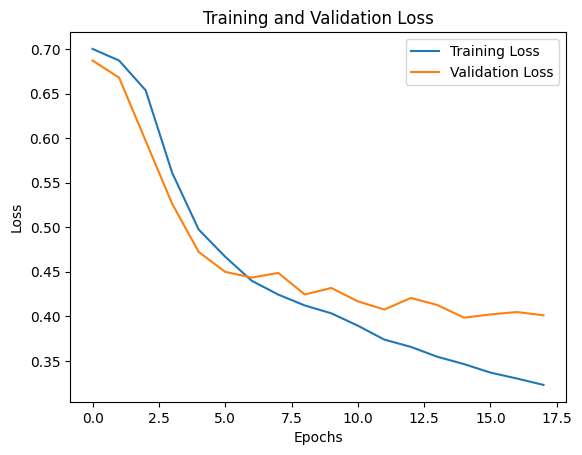

In [28]:
# Plot the training and validation loss
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
# Add title and axis labels
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
# Show the legend
plt.legend()
# Display the plot
plt.show()

## Fine tuning BioMedCLIP with LoRA (Low Rank Adaptation)

In [7]:
lora_X_train, lora_X_test, lora_y_train, lora_y_test = X_train_cross_att.copy(), X_test_cross_att.copy(), y_train_cross_att.copy(), y_test_cross_att.copy()
lora_X_train = lora_X_train.reset_index(drop=True)
lora_X_test = lora_X_test.reset_index(drop=True)
lora_y_train = lora_y_train.reset_index(drop=True)
lora_y_test = lora_y_test.reset_index(drop=True)

In [8]:
clip_lora_model, lora_preprocess_train, lora_preprocess_val = create_model_and_transforms('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
lora_tokenizer = get_tokenizer('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')

In [9]:
class LoraDataset(Dataset):
    def __init__(self, dataframe, labels):
        self.dataframe = dataframe
        self.labels = labels
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        # Load raw data
        raw_image_path = "./CheXpert/CheXpert-v1.0-small/" + self.dataframe.loc[idx, "path_to_image"]
        raw_report_text = self.dataframe.loc[idx, "report"]
        label = self.labels[idx]
        
        # Transform raw pixels into a 3x224x224 tensor
        pil_img = Image.open(raw_image_path).convert("RGB")
        processed_image_tensor = lora_preprocess_train(pil_img) # Shape: [3, 224, 224]
        
        # Transform raw string into a 256-long token ID tensor
        tokenized_text_tensor = lora_tokenizer(raw_report_text, context_length=256).squeeze(0) # Shape: [256]
        
        return processed_image_tensor, tokenized_text_tensor, torch.tensor(label, dtype=torch.float32)


In [10]:
lora_train_dataset = LoraDataset(lora_X_train, lora_y_train)
lora_test_dataset = LoraDataset(lora_X_test, lora_y_test)

lora_train_loader = DataLoader(lora_train_dataset, batch_size=32, shuffle=True)
lora_val_loader = DataLoader(lora_test_dataset, batch_size=32, shuffle=False)

In [11]:
class LoraClassifier(nn.Module):
    def __init__(self, embed_dim=768, num_heads=8, dropout=0.3):
        super().__init__()
        
        self.cross_attention = nn.MultiheadAttention(
                    embed_dim=embed_dim, 
                    num_heads=num_heads, 
                    dropout=dropout,
                    batch_first=True
                )
        
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.layer_norm2 = nn.LayerNorm(embed_dim)
    
        # Add a small Feed-Forward Network layer (FFN) inside the attention block 
        # This mirrors a true standard Transformer block and stabilizes representation warping
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim)
        )
    
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.LayerNorm(256), # BatchNorm stabilizes linear scaling transitions!
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )
        
    def forward(self, img_patches, text_tokens):
        norm_text = self.layer_norm1(text_tokens)
        # Cross-Attention Core
        attn_output, _ = self.cross_attention(
            query=norm_text, 
            key=img_patches, 
            value=img_patches
        )
        x = (attn_output + text_tokens)
        
        # FFN stabilization step
        x = self.layer_norm2(self.ffn(x)) + x
        
        # Max-pooling across sequence dimension 
        # This captures the strongest text-visual features and ignores inactive padding tokens
        x_pooled, _ = torch.max(x, dim=1)
        # Predict
        return self.classifier(x_pooled)

In [12]:
class BioMedCLIPWithLoRA(nn.Module):
    def __init__(self, biomedclip_base_model, r=8, alpha=16):
        super().__init__()
        
        # Target the Attention projections of BioMedCLIP.
        lora_config = LoraConfig(
            r=r,
            lora_alpha=alpha,
            target_modules=["qkv", "query", "value"], 
            lora_dropout=0.1,
            bias="none"
        )
        
        # Wrap the base model. PEFT automatically freezes base weights 
        # and injects the trainable A and B matrices into the target_modules.
        self.biomedclip = get_peft_model(biomedclip_base_model, lora_config)
        
        # Instantiate custom fusion head
        self.fusion_head = LoraClassifier()
        
    def forward(self, image_tensors, token_id_tensors):
        # Extract text tokens (Confirmed 3D: [Batch, 256, 768])
        text_outputs = self.biomedclip.base_model.model.text.transformer(token_id_tensors)
        text_tokens = text_outputs.last_hidden_state 
        
        # Extract raw image tokens from the timm Vision Transformer
        img_patches = self.biomedclip.base_model.model.visual.trunk.forward_features(image_tensors)
        
        # To get the unpooled patch grid, we pull the features right before the head.
        if len(img_patches.shape) == 2:
            # Extract from the patch embedding and transformer blocks directly
            # This completely bypasses any global pooling settings in the trunk wrapper
            x = self.biomedclip.base_model.model.visual.trunk.patch_embed(image_tensors)
            x = self.biomedclip.base_model.model.visual.trunk._pos_embed(x)
            x = self.biomedclip.base_model.model.visual.trunk.patch_drop(x)
            x = self.biomedclip.base_model.model.visual.trunk.norm_pre(x)
            img_patches = self.biomedclip.base_model.model.visual.trunk.blocks(x)
            img_patches = self.biomedclip.base_model.model.visual.trunk.norm(img_patches)
            
        
        # Both are now guaranteed tensors of shape:
        # Text: [Batch, 256, 768]
        # Vision: [Batch, 197, 768]
        return self.fusion_head(img_patches, text_tokens)

In [13]:
def lora_train(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=100, patience=3):
    """
    Function to train a PyTorch model with training and validation datasets.

    Parameters:
    model: The neural network model to train.
    train_loader: DataLoader for the training dataset.
    val_loader: DataLoader for the validation dataset.
    criterion: Loss function (e.g., Binary Cross Entropy for classification).
    optimizer: Optimization algorithm (e.g., Adam, SGD).
    epochs: Number of training epochs (default=100).

    Returns:
    history: Dictionary containing loss and accuracy for both training and validation.
    """

    # Dictionary to store training & validation loss and accuracy over epochs
    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

    # Initialize GradScaler for Mixed Precision (handles FP16 scaling)
    scaler = GradScaler('cuda')

    # Early stopping trackers
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = None
    best_epoch = 0

    for epoch in range(epochs):  # Loop over the number of epochs
        model.train()  # Set model to training mode
        total_loss, correct = 0, 0  # Initialize total loss and correct predictions

        # Training loop
        for inputs_img, inputs_txt, labels in train_loader:
            inputs_img = inputs_img.to(device, non_blocking=True)
            inputs_txt = inputs_txt.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast('cuda'):
                outputs = model(inputs_img, inputs_txt).squeeze(1)  # Forward pass
                loss = criterion(outputs, labels)  # Compute loss
            # Scale loss and backpropagate in mixed precision
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            # loss.backward()  # Backpropagation (compute gradients)
            # optimizer.step()  # Update model parameters

            total_loss += loss.item()  # Accumulate batch loss
            correct += ((torch.sigmoid(outputs) >= 0.5).float() == labels).sum().item()  # Count correct predictions

        # Compute average loss and accuracy for training
        train_loss = total_loss / len(train_loader)
        train_acc = correct / len(train_loader.dataset)

        # Validation phase (without gradient computation)
        model.eval()  # Set model to evaluation mode
        val_loss, val_correct = 0, 0
        with torch.no_grad():  # No need to compute gradients during validation
            for inputs_img, inputs_txt, labels in val_loader:
                inputs_img = inputs_img.to(device, non_blocking=True)
                inputs_txt = inputs_txt.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                with autocast('cuda'):
                    outputs = model(inputs_img, inputs_txt).squeeze(1) # Forward pass
                    loss = criterion(outputs, labels)  # Compute loss
                val_loss += loss.item()  # Accumulate validation loss
                val_correct += ((torch.sigmoid(outputs) >= 0.5).float() == labels).sum().item()  # Count correct predictions

        # Compute average loss and accuracy for validation
        val_loss /= len(val_loader)
        val_acc = val_correct / len(val_loader.dataset)
        
        scheduler.step()
        # Capture current learning rate for tracking
        current_lr = optimizer.param_groups[0]['lr']

        # Store metrics in history dictionary
        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)

        # Print training progress
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, LR: {current_lr:.6f}")

        # --- Early Stopping Logic ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0  # Reset counter since we found a better model
            best_epoch = epoch + 1
            # Cache a deep copy of the optimal weights
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            print(f"-> Validation loss did not improve. Early Stopping Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n🛑 Early stopping triggered! Stopping training at epoch {epoch+1}.")
            break

    # --- Restore Best Weights ---
    if best_model_weights is not None:
        print(f"✅ Restoring best model weights found at Epoch {best_epoch} (Val Loss: {best_val_loss:.4f})")
        model.load_state_dict(best_model_weights)
        
    return history  # Return training history


In [14]:
# Clear Python's main garbage collector
gc.collect()

# Clear the PyTorch VRAM cache
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lora_model = BioMedCLIPWithLoRA(biomedclip_base_model=clip_lora_model, r=8, alpha=16).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(lora_model.parameters(), lr=1e-5, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)



In [15]:
summary(lora_model)

Layer (type:depth-idx)                                                                Param #
BioMedCLIPWithLoRA                                                                    --
├─PeftModel: 1-1                                                                      --
│    └─LoraModel: 2-1                                                                 --
│    │    └─CustomTextCLIP: 3-1                                                       196,492,545
├─LoraClassifier: 1-2                                                                 --
│    └─MultiheadAttention: 2-2                                                        1,771,776
│    │    └─NonDynamicallyQuantizableLinear: 3-2                                      590,592
│    └─LayerNorm: 2-3                                                                 1,536
│    └─LayerNorm: 2-4                                                                 1,536
│    └─Sequential: 2-5                                                        

In [16]:
# Launch the training block
history_lora = lora_train(
    model=lora_model, 
    train_loader=lora_train_loader, 
    val_loader=lora_val_loader, 
    criterion=criterion, 
    optimizer=optimizer, 
    scheduler = scheduler,
    epochs=50
)

Epoch [1/50], Loss: 0.7044, Acc: 0.5138, Val Loss: 0.6812, Val Acc: 0.5709, LR: 0.000010
Epoch [2/50], Loss: 0.6842, Acc: 0.5505, Val Loss: 0.6393, Val Acc: 0.6245, LR: 0.000010
Epoch [3/50], Loss: 0.5741, Acc: 0.6924, Val Loss: 0.5017, Val Acc: 0.7539, LR: 0.000010
Epoch [4/50], Loss: 0.4874, Acc: 0.7600, Val Loss: 0.4791, Val Acc: 0.7759, LR: 0.000010
Epoch [5/50], Loss: 0.4474, Acc: 0.7872, Val Loss: 0.4303, Val Acc: 0.7973, LR: 0.000010
Epoch [6/50], Loss: 0.4211, Acc: 0.7995, Val Loss: 0.4412, Val Acc: 0.7923, LR: 0.000010
-> Validation loss did not improve. Early Stopping Patience: 1/3
Epoch [7/50], Loss: 0.4005, Acc: 0.8167, Val Loss: 0.3957, Val Acc: 0.8152, LR: 0.000010
Epoch [8/50], Loss: 0.3870, Acc: 0.8266, Val Loss: 0.3991, Val Acc: 0.8182, LR: 0.000009
-> Validation loss did not improve. Early Stopping Patience: 1/3
Epoch [9/50], Loss: 0.3675, Acc: 0.8375, Val Loss: 0.3847, Val Acc: 0.8252, LR: 0.000009
Epoch [10/50], Loss: 0.3608, Acc: 0.8354, Val Loss: 0.3769, Val Acc: 

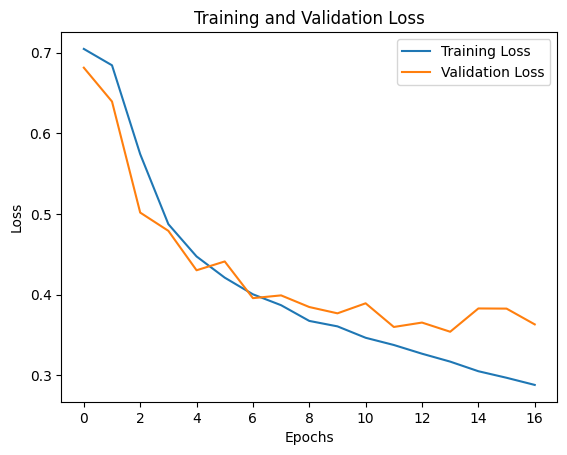

In [18]:
# Plot the training and validation loss
plt.plot(history_lora["loss"], label="Training Loss")
plt.plot(history_lora["val_loss"], label="Validation Loss")
# Add title and axis labels
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
# Show the legend
plt.legend()
# Display the plot
plt.show()